In [12]:
import dask.dataframe as dd
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from xgboost import XGBClassifier
import numpy as np
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

In [13]:
filePaths = ["Data/jane-street-real-time-market-data-forecasting/train.parquet/partition_id=0/part-0.parquet",
                  "Data/jane-street-real-time-market-data-forecasting/train.parquet/partition_id=1/part-0.parquet",
                  "Data/jane-street-real-time-market-data-forecasting/train.parquet/partition_id=2/part-0.parquet",
                  "Data/jane-street-real-time-market-data-forecasting/train.parquet/partition_id=3/part-0.parquet",
                  "Data/jane-street-real-time-market-data-forecasting/train.parquet/partition_id=4/part-0.parquet",
                  "Data/jane-street-real-time-market-data-forecasting/train.parquet/partition_id=5/part-0.parquet",
                  "Data/jane-street-real-time-market-data-forecasting/train.parquet/partition_id=6/part-0.parquet",
                  "Data/jane-street-real-time-market-data-forecasting/train.parquet/partition_id=7/part-0.parquet",
                  "Data/jane-street-real-time-market-data-forecasting/train.parquet/partition_id=8/part-0.parquet",
                  "Data/jane-street-real-time-market-data-forecasting/train.parquet/partition_id=9/part-0.parquet"
                  ]
df = dd.read_parquet(filePaths)

In [14]:
# Drop rows with NaN values in the following columns because they have very few NaN values
columns = ['feature_08', 'feature_15', 'feature_16', 'feature_17', 'feature_18', 'feature_19', 
               'feature_32', 'feature_33', 'feature_37', 'feature_40', 'feature_41', 'feature_44', 
               'feature_45', 'feature_46', 'feature_47', 'feature_51', 'feature_52', 'feature_54', 
               'feature_55', 'feature_56', 'feature_57', 'feature_58', 'feature_62', 'feature_63', 
               'feature_64', 'feature_66', 'feature_73', 'feature_74', 'feature_75', 'feature_76', 
               'feature_77', 'feature_78']
df = df.dropna(subset=columns)

In [15]:
nanCol = ['feature_39', 'feature_42', 'feature_50', 'feature_53']
def imputePartition(partition):
    imputer = IterativeImputer(max_iter=10, random_state=42)
    partition[nanCol] = imputer.fit_transform(partition[nanCol])
    return partition

df = df.map_partitions(imputePartition)

In [16]:
features = ['feature_00','feature_01','feature_02','feature_03','feature_04','feature_05','feature_06','feature_07','feature_08','feature_09','feature_10','feature_11','feature_12','feature_13','feature_14','feature_15','feature_16','feature_17','feature_18','feature_19','feature_20','feature_21','feature_22','feature_23','feature_24','feature_25','feature_26','feature_27','feature_28','feature_29','feature_30','feature_31','feature_32','feature_33','feature_34','feature_35','feature_36','feature_37','feature_38','feature_39','feature_40','feature_41','feature_42','feature_43','feature_44','feature_45','feature_46','feature_47','feature_48','feature_49','feature_50','feature_51','feature_52','feature_53','feature_54','feature_55','feature_56','feature_57','feature_58','feature_59','feature_60','feature_61','feature_62','feature_63','feature_64','feature_65','feature_66','feature_67','feature_68','feature_69','feature_70','feature_71','feature_72','feature_73','feature_74','feature_75','feature_76','feature_77','feature_78']
responders = ['responder_0','responder_1','responder_2','responder_3','responder_4','responder_5','responder_6','responder_7','responder_8']
target = ['responder_6']

In [17]:
dfFeatures = df[features]
dfResponders = df[responders]
dfTarget = df[target]

In [18]:
sampledf = dfFeatures.sample(frac=0.001)  
sampledf = sampledf.compute()

output_dir = './Plots/Feature Plots'
os.makedirs(output_dir, exist_ok=True)  

for feature in features:
    plt.figure(figsize=(8, 6))
    sns.histplot(sampledf[feature], kde=True, bins=30)
    plt.title(f'Distribution of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Frequency')
    plt.tight_layout()
    plot_path = os.path.join(output_dir, f'{feature}.png')
    plt.savefig(plot_path)
    plt.close()

In [19]:
standardizedFeatures = StandardScaler().fit_transform(sampledf[features])
sampleStandardFeatures = pd.DataFrame(standardizedFeatures, columns=features)

In [20]:
sampledf = dfResponders.sample(frac=0.001)  
sampledf = sampledf.compute()

output_dir = './Plots/Responder Plots'
os.makedirs(output_dir, exist_ok=True)  

for responder in responders:
    plt.figure(figsize=(8, 6))
    sns.histplot(sampledf[responder], kde=True, bins=30)
    plt.title(f'Distribution of {responder}')
    plt.xlabel(responder)
    plt.ylabel('Frequency')
    plt.tight_layout()
    plot_path = os.path.join(output_dir, f'{responder}.png')
    plt.savefig(plot_path)
    plt.close()

In [21]:
standardizedResponders = StandardScaler().fit_transform(sampledf[responders])
sampleStandardResponders = pd.DataFrame(standardizedResponders, columns=responders)

In [22]:
corrMatrix = sampleStandardFeatures.corr()
corrMatrix.to_csv('./Info/CorrelationMatrix.csv')


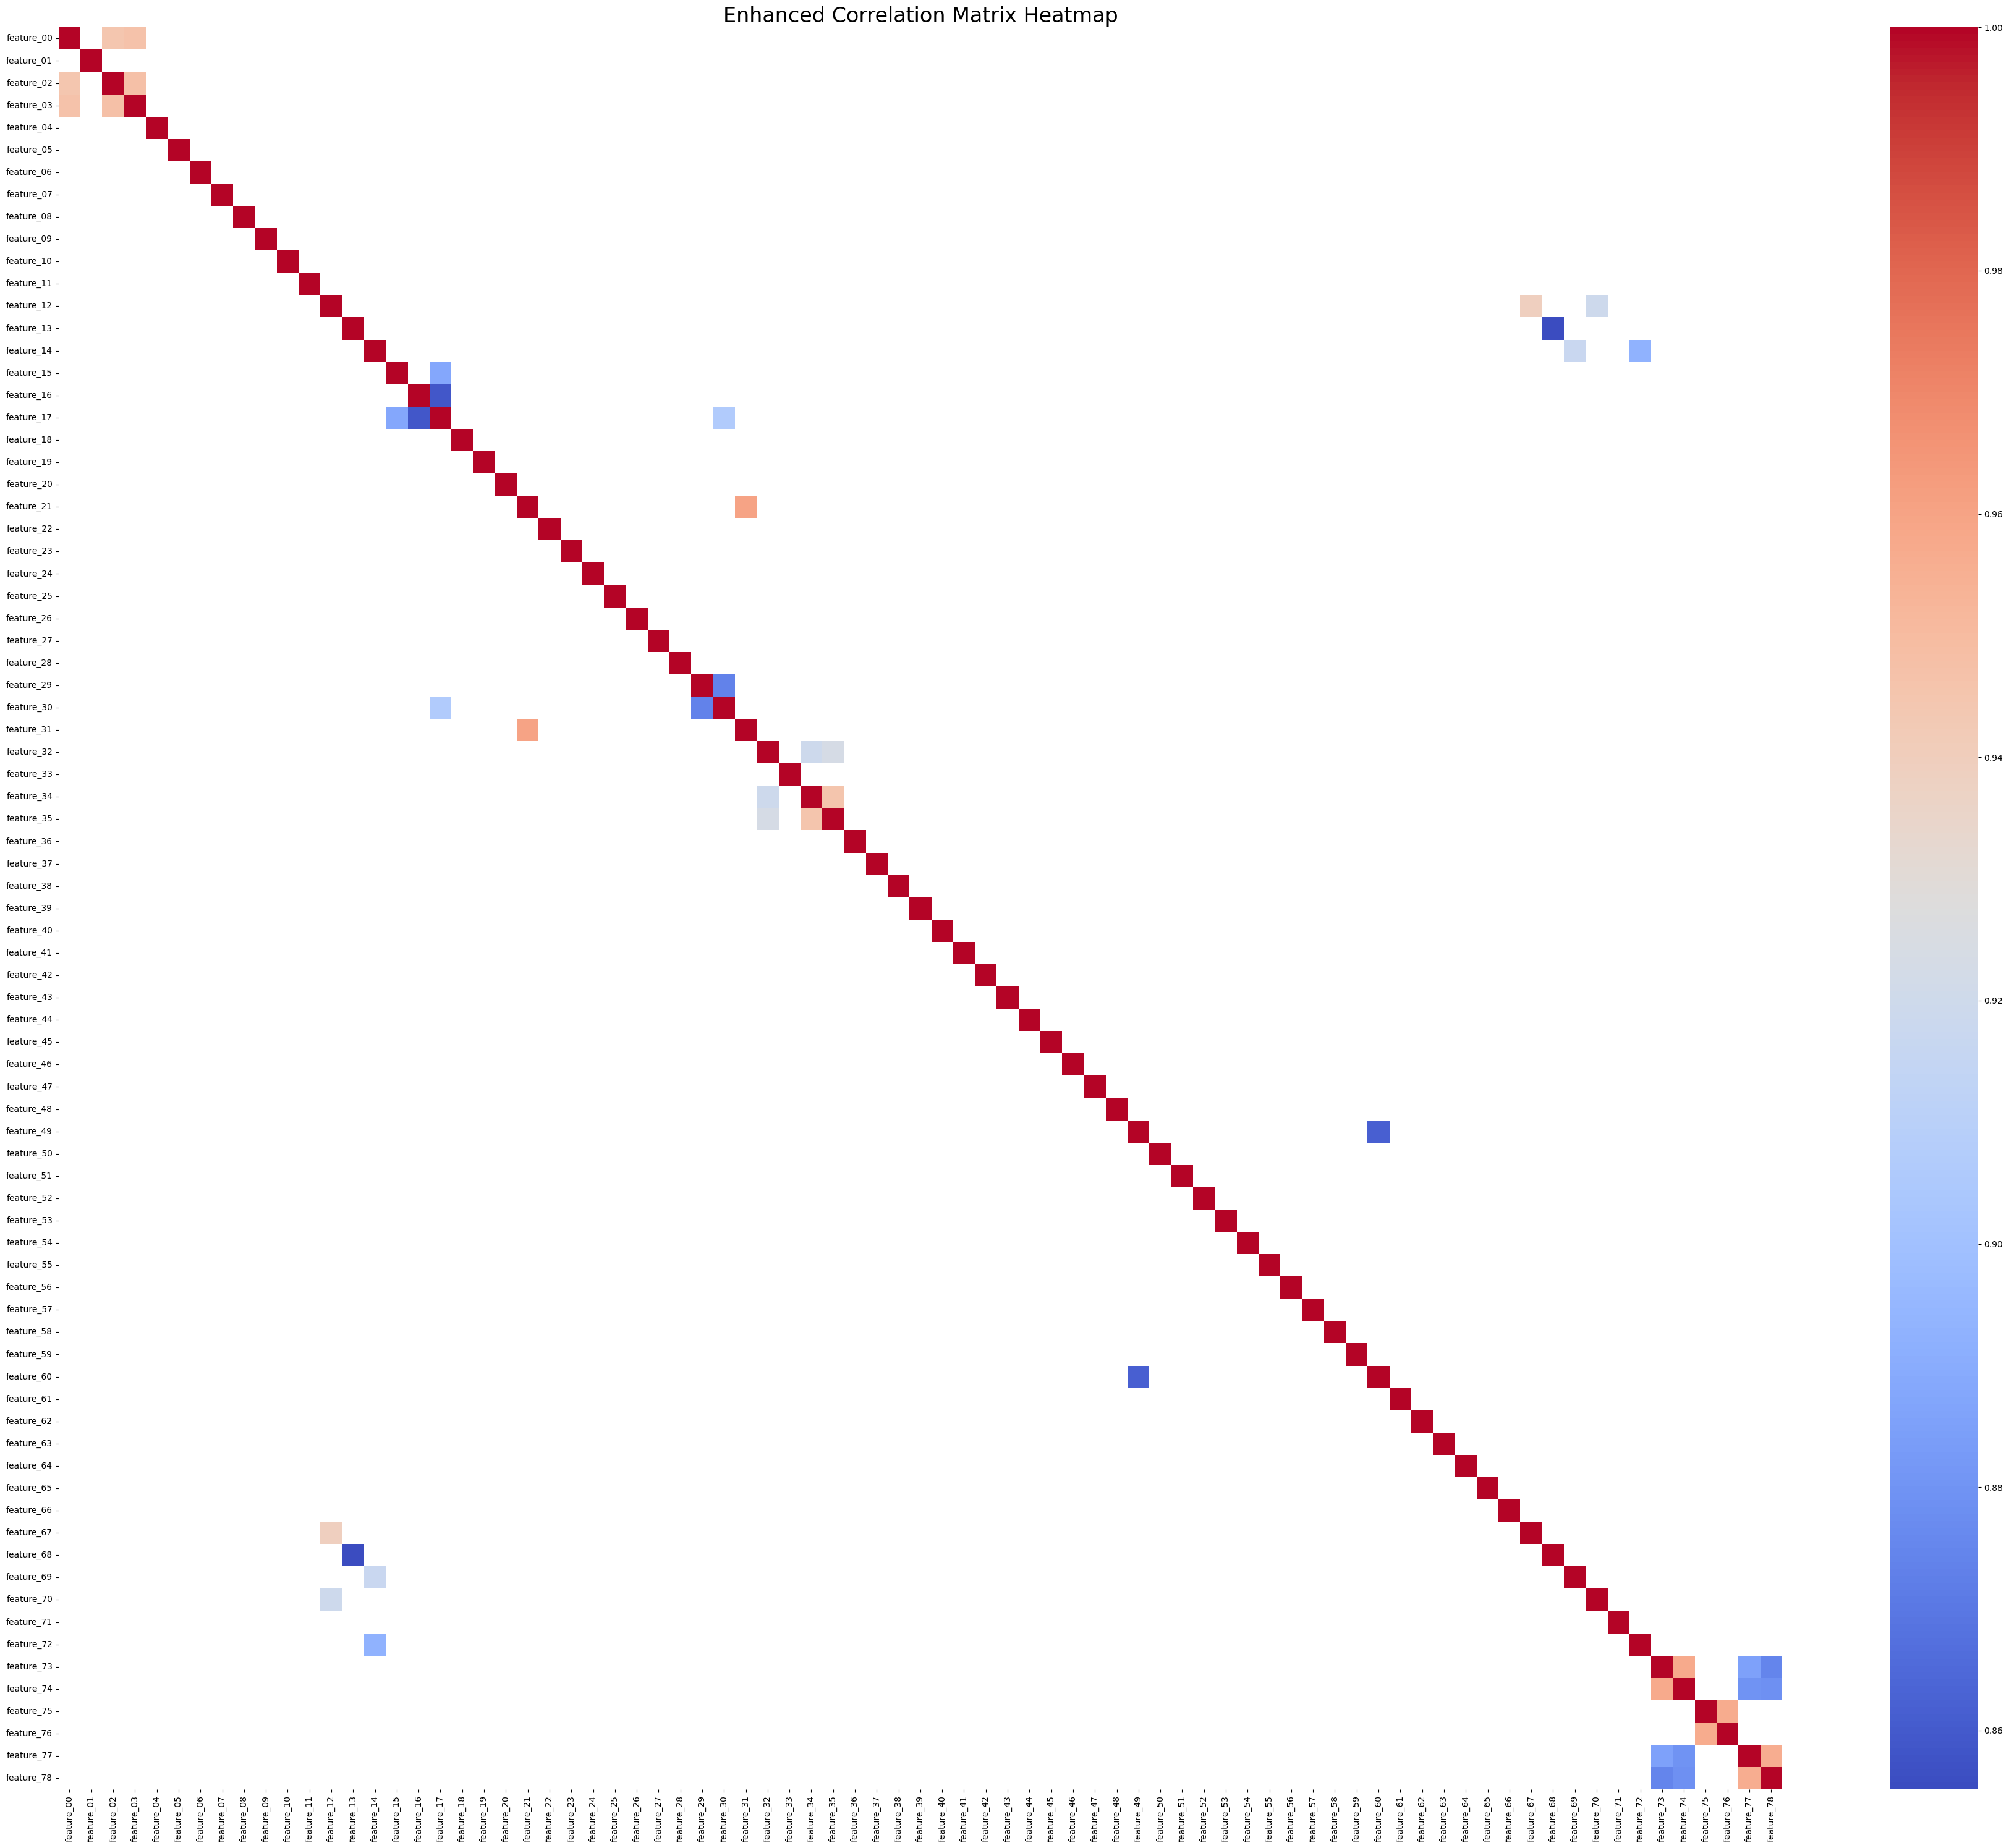

In [23]:
plt.figure(figsize=(36, 30))
sns.heatmap(
    corrMatrix, 
    annot=False, 
    cmap='coolwarm', 
    cbar=True, 
    mask=corrMatrix.abs() < 0.85
)
plt.xticks(fontsize=10)  
plt.yticks(fontsize=10)  
plt.title('Enhanced Correlation Matrix Heatmap', fontsize=24)
plt.tight_layout()
plt.savefig("./Plots/Correlation Matrix/85+.png")
plt.show()
plt.close()

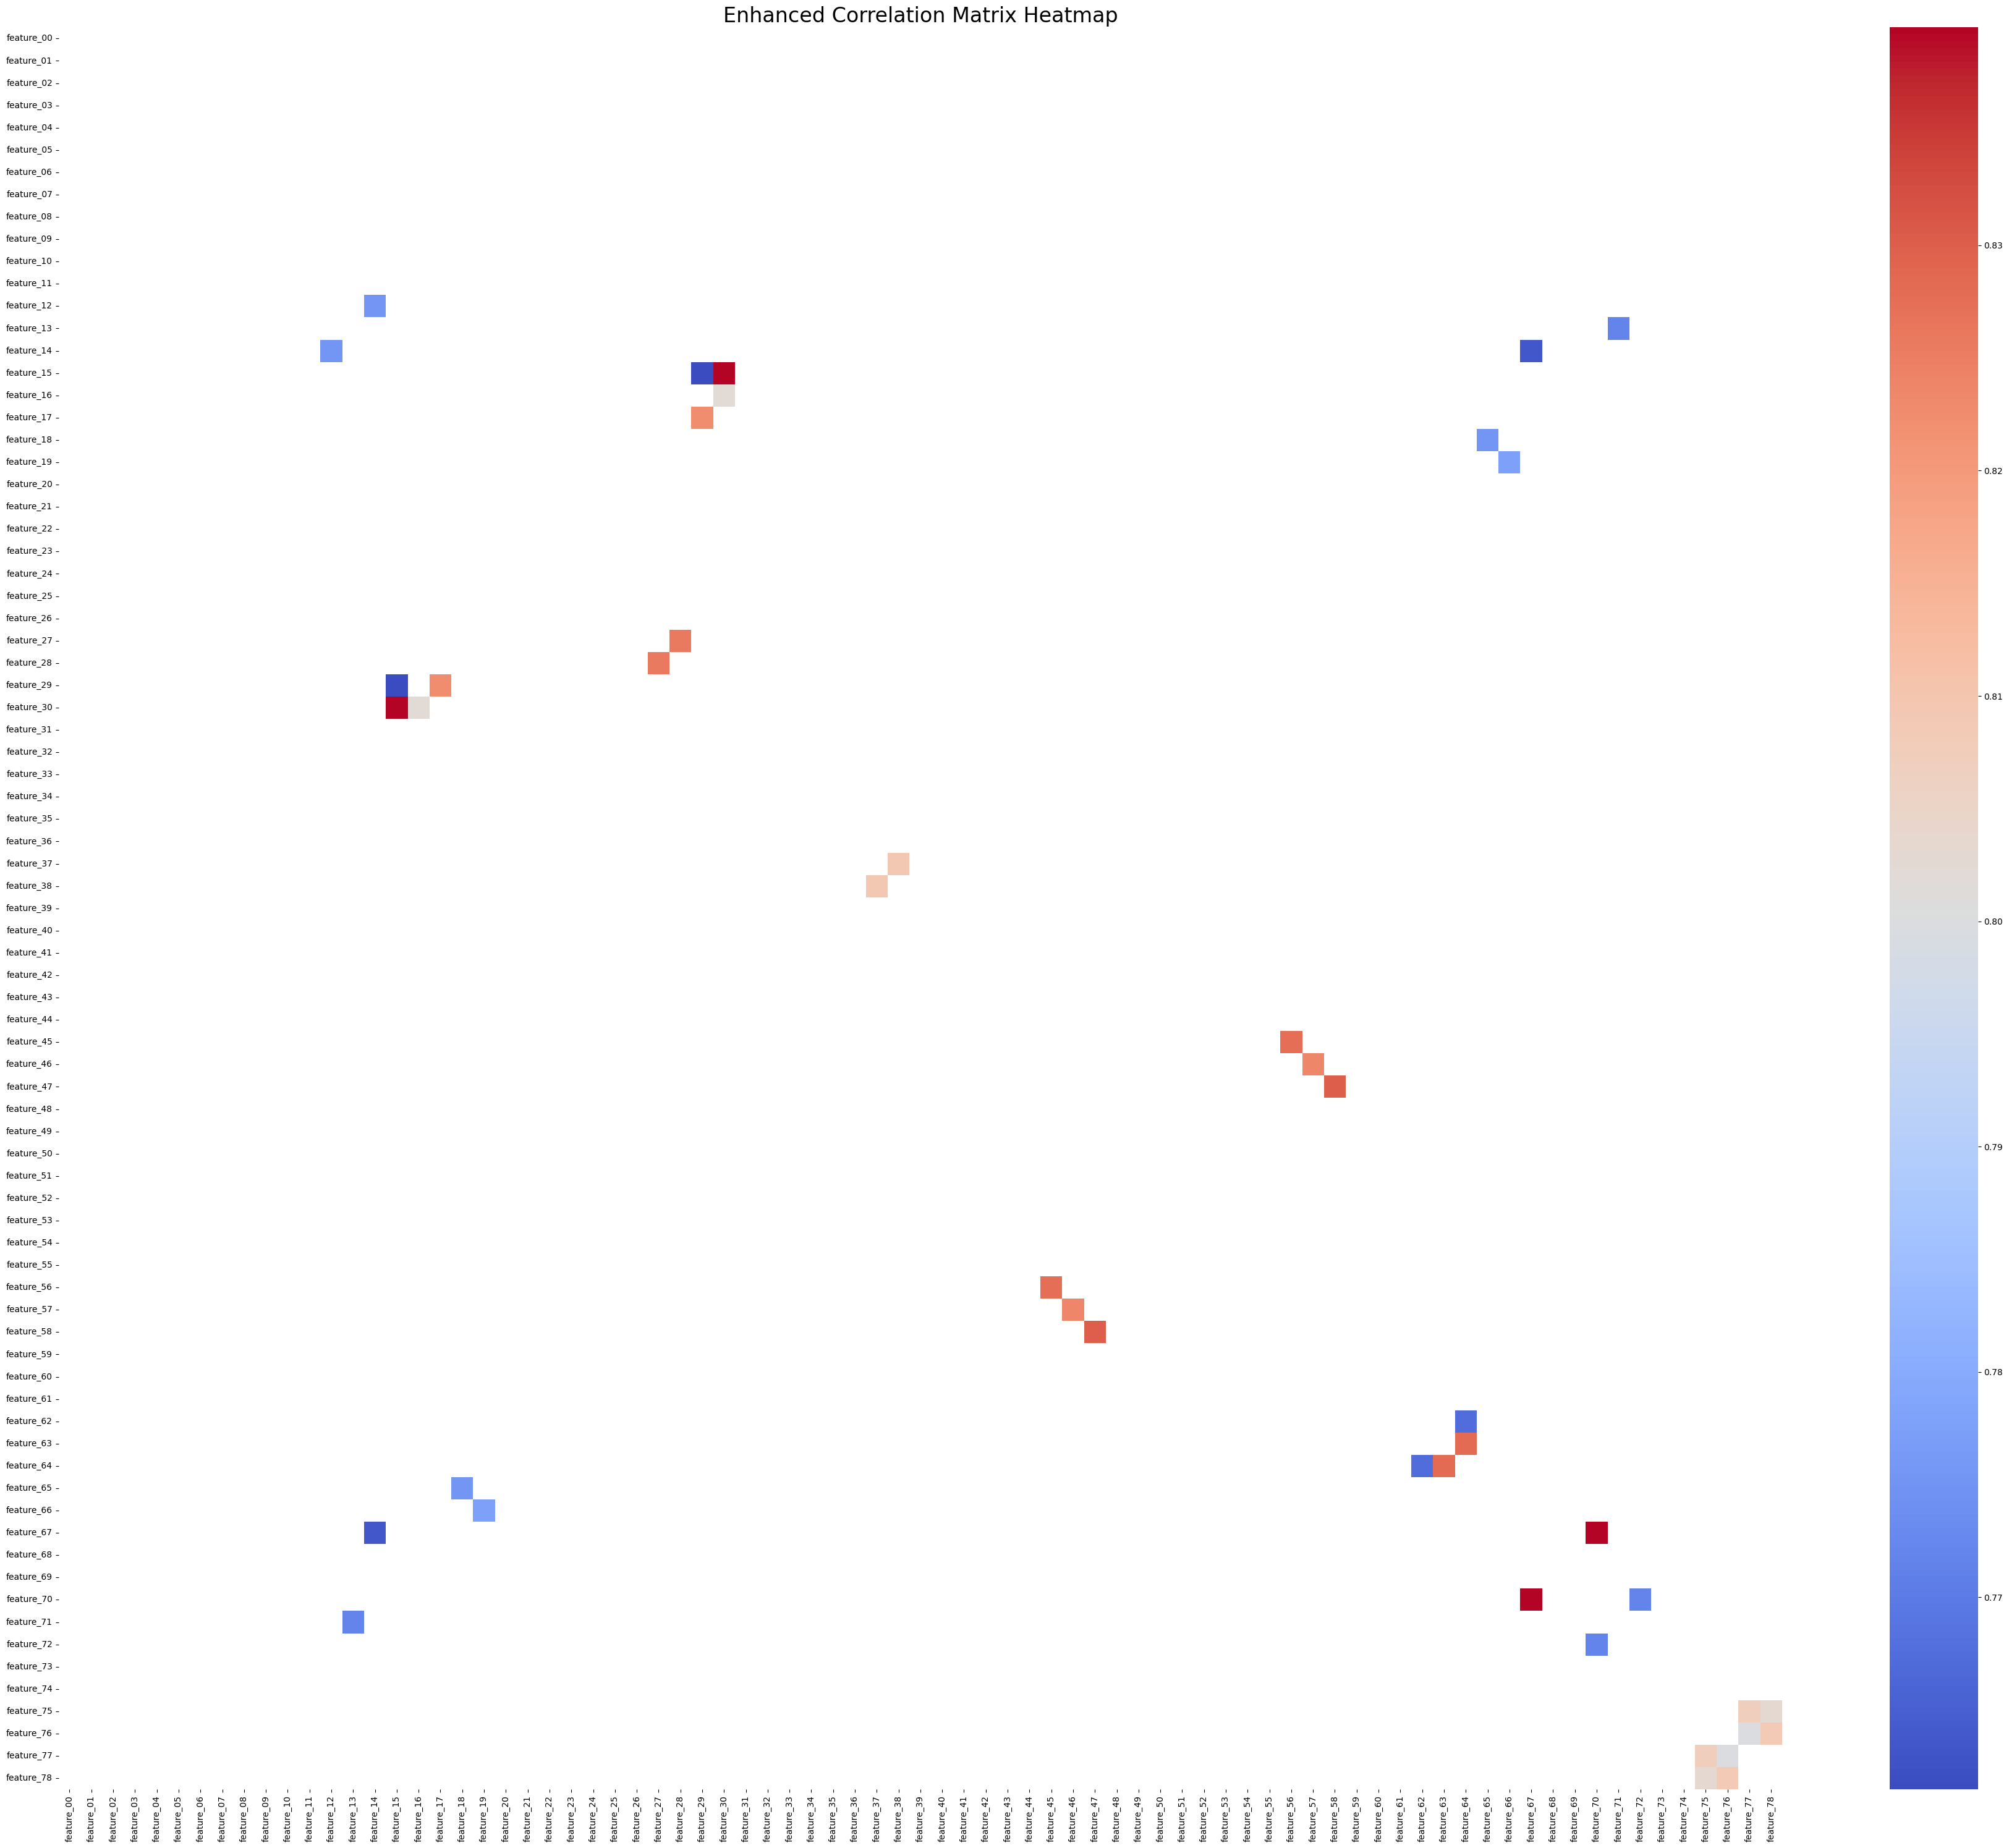

In [24]:
plt.figure(figsize=(36, 30))
mask = (corrMatrix.abs() < 0.75) | (corrMatrix.abs() > 0.85)
sns.heatmap(
    corrMatrix, 
    annot=False, 
    cmap='coolwarm', 
    cbar=True, 
    mask=mask
)
plt.xticks(fontsize=10)  
plt.yticks(fontsize=10)  
plt.title('Enhanced Correlation Matrix Heatmap', fontsize=24)
plt.tight_layout()
plt.savefig("./Plots/Correlation Matrix/75-85.png")
plt.show()
plt.close()

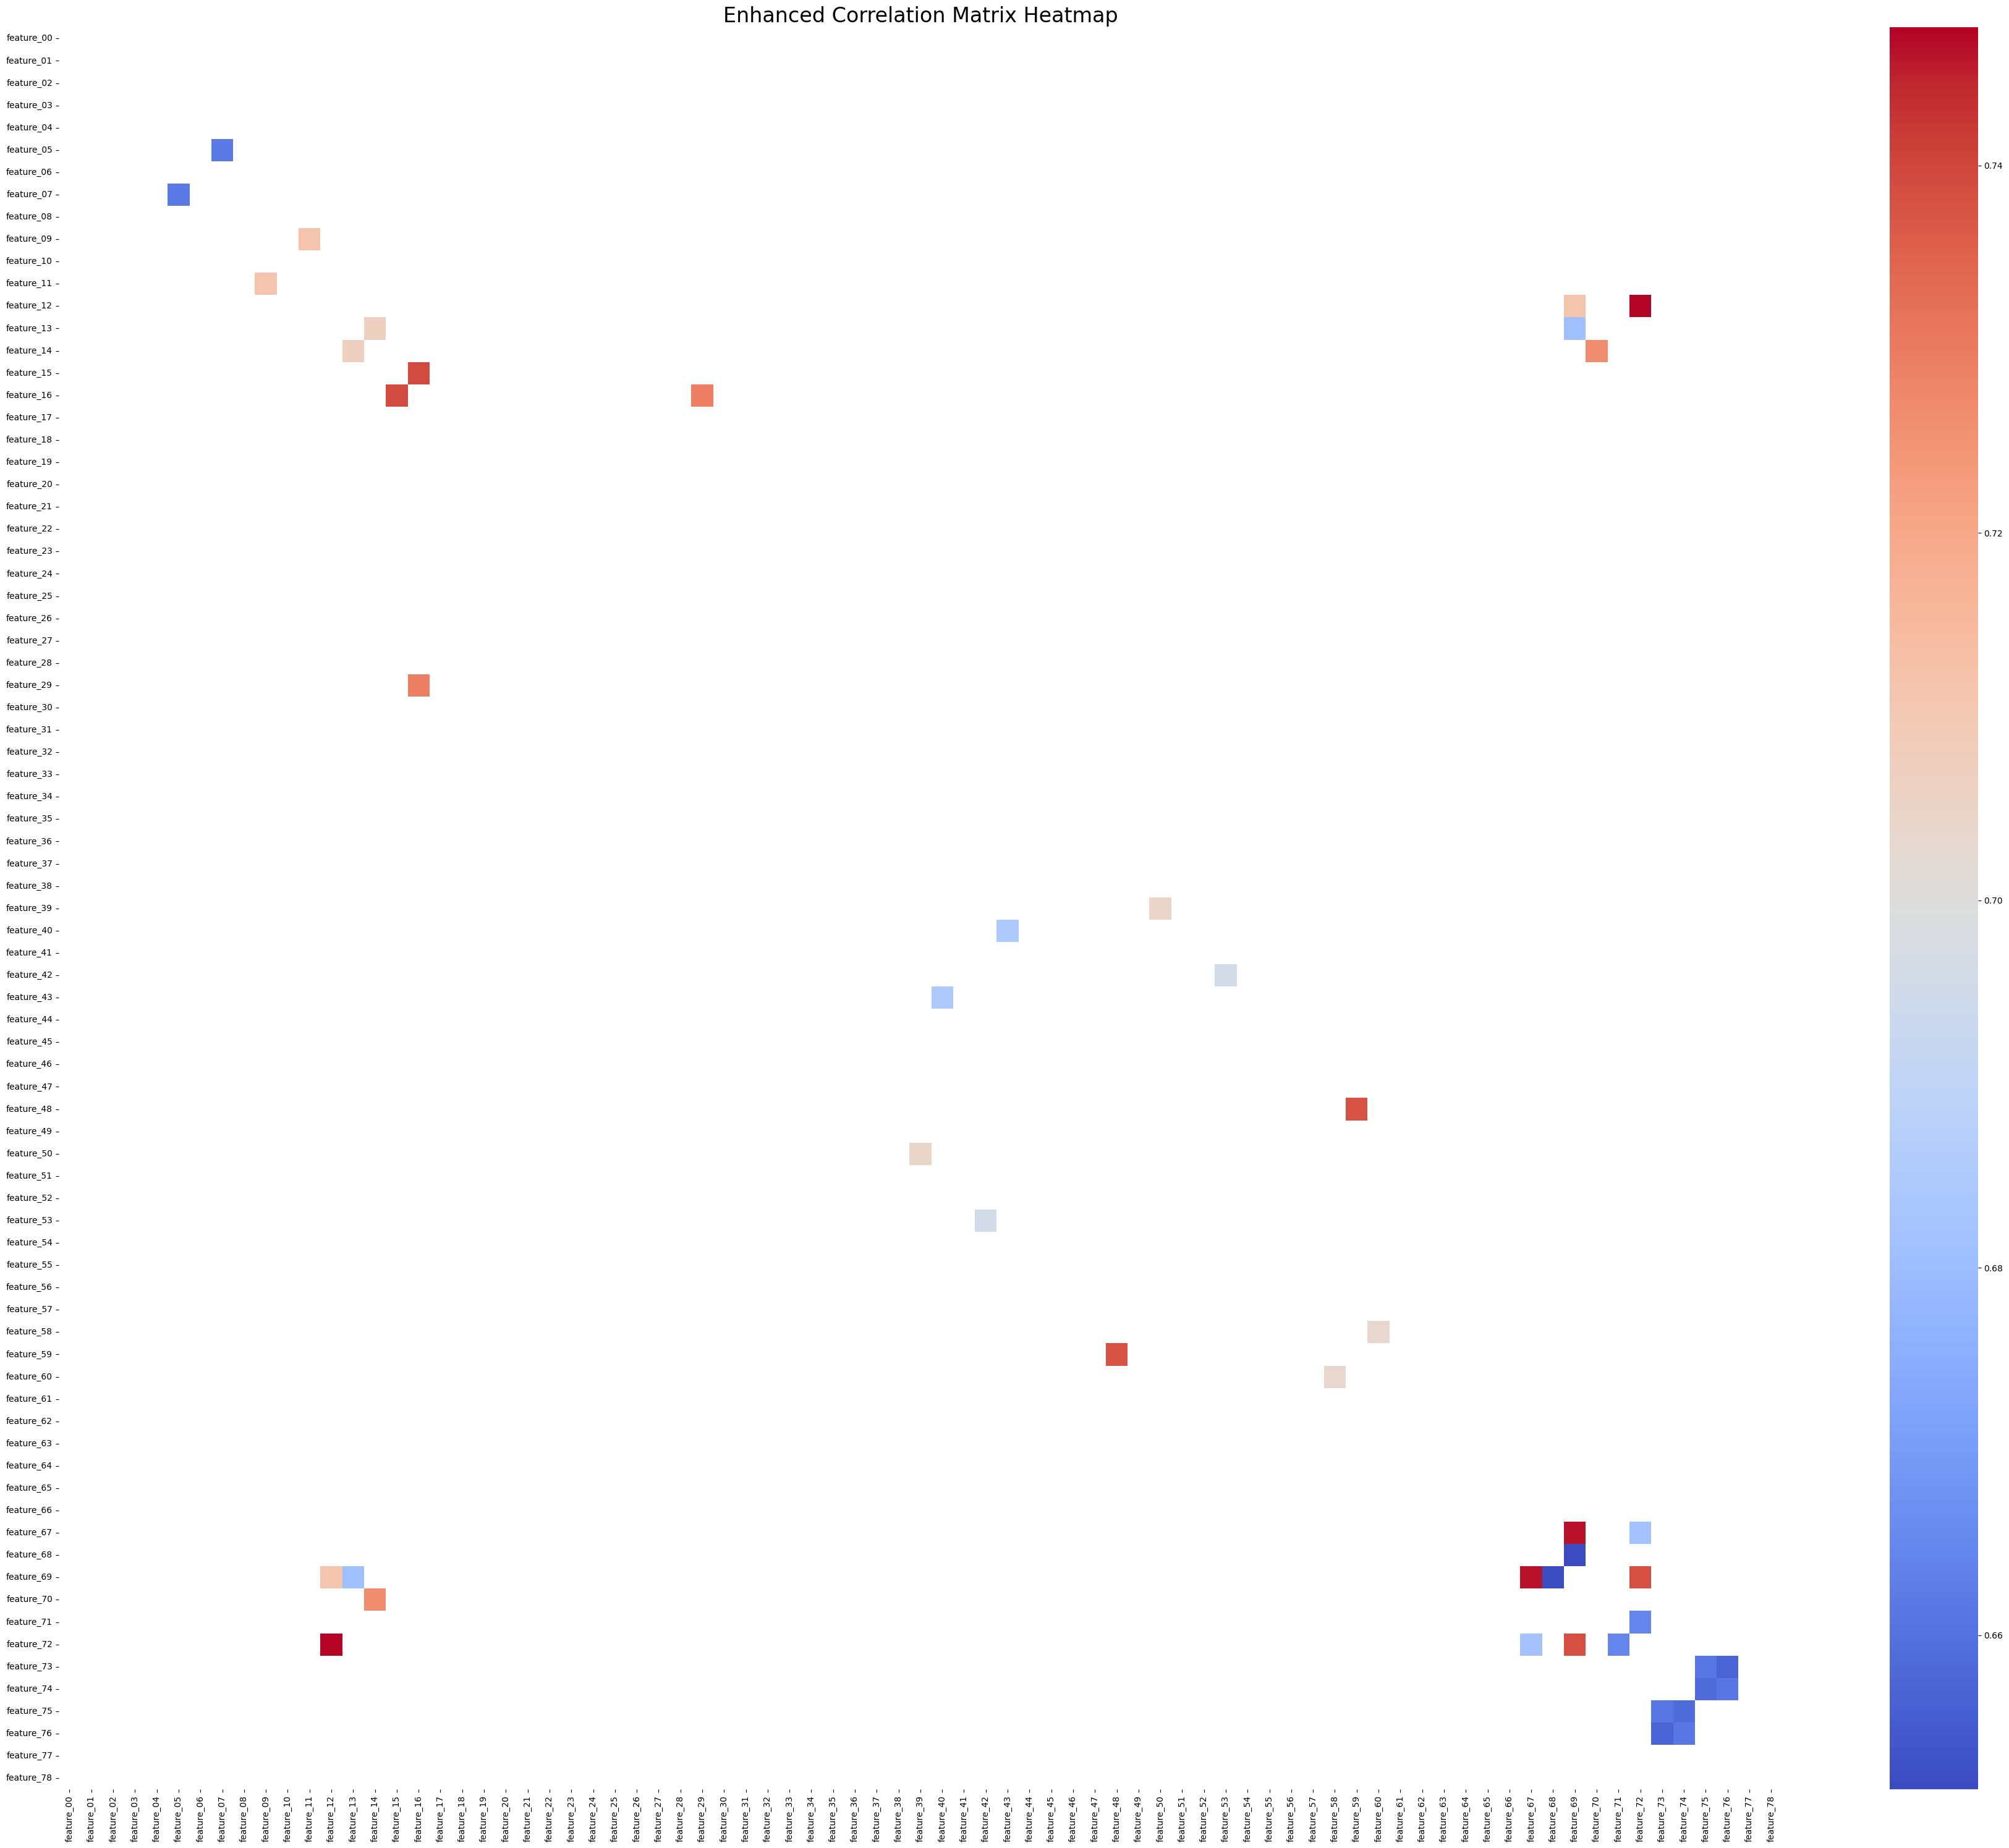

In [25]:
plt.figure(figsize=(36, 30))
mask = (corrMatrix.abs() < 0.65) | (corrMatrix.abs() > 0.75)
sns.heatmap(
    corrMatrix, 
    annot=False, 
    cmap='coolwarm', 
    cbar=True, 
    mask=mask
)
plt.xticks(fontsize=10)  
plt.yticks(fontsize=10)  
plt.title('Enhanced Correlation Matrix Heatmap', fontsize=24)
plt.tight_layout()
plt.savefig("./Plots/Correlation Matrix/65-75.png")
plt.show()
plt.close()

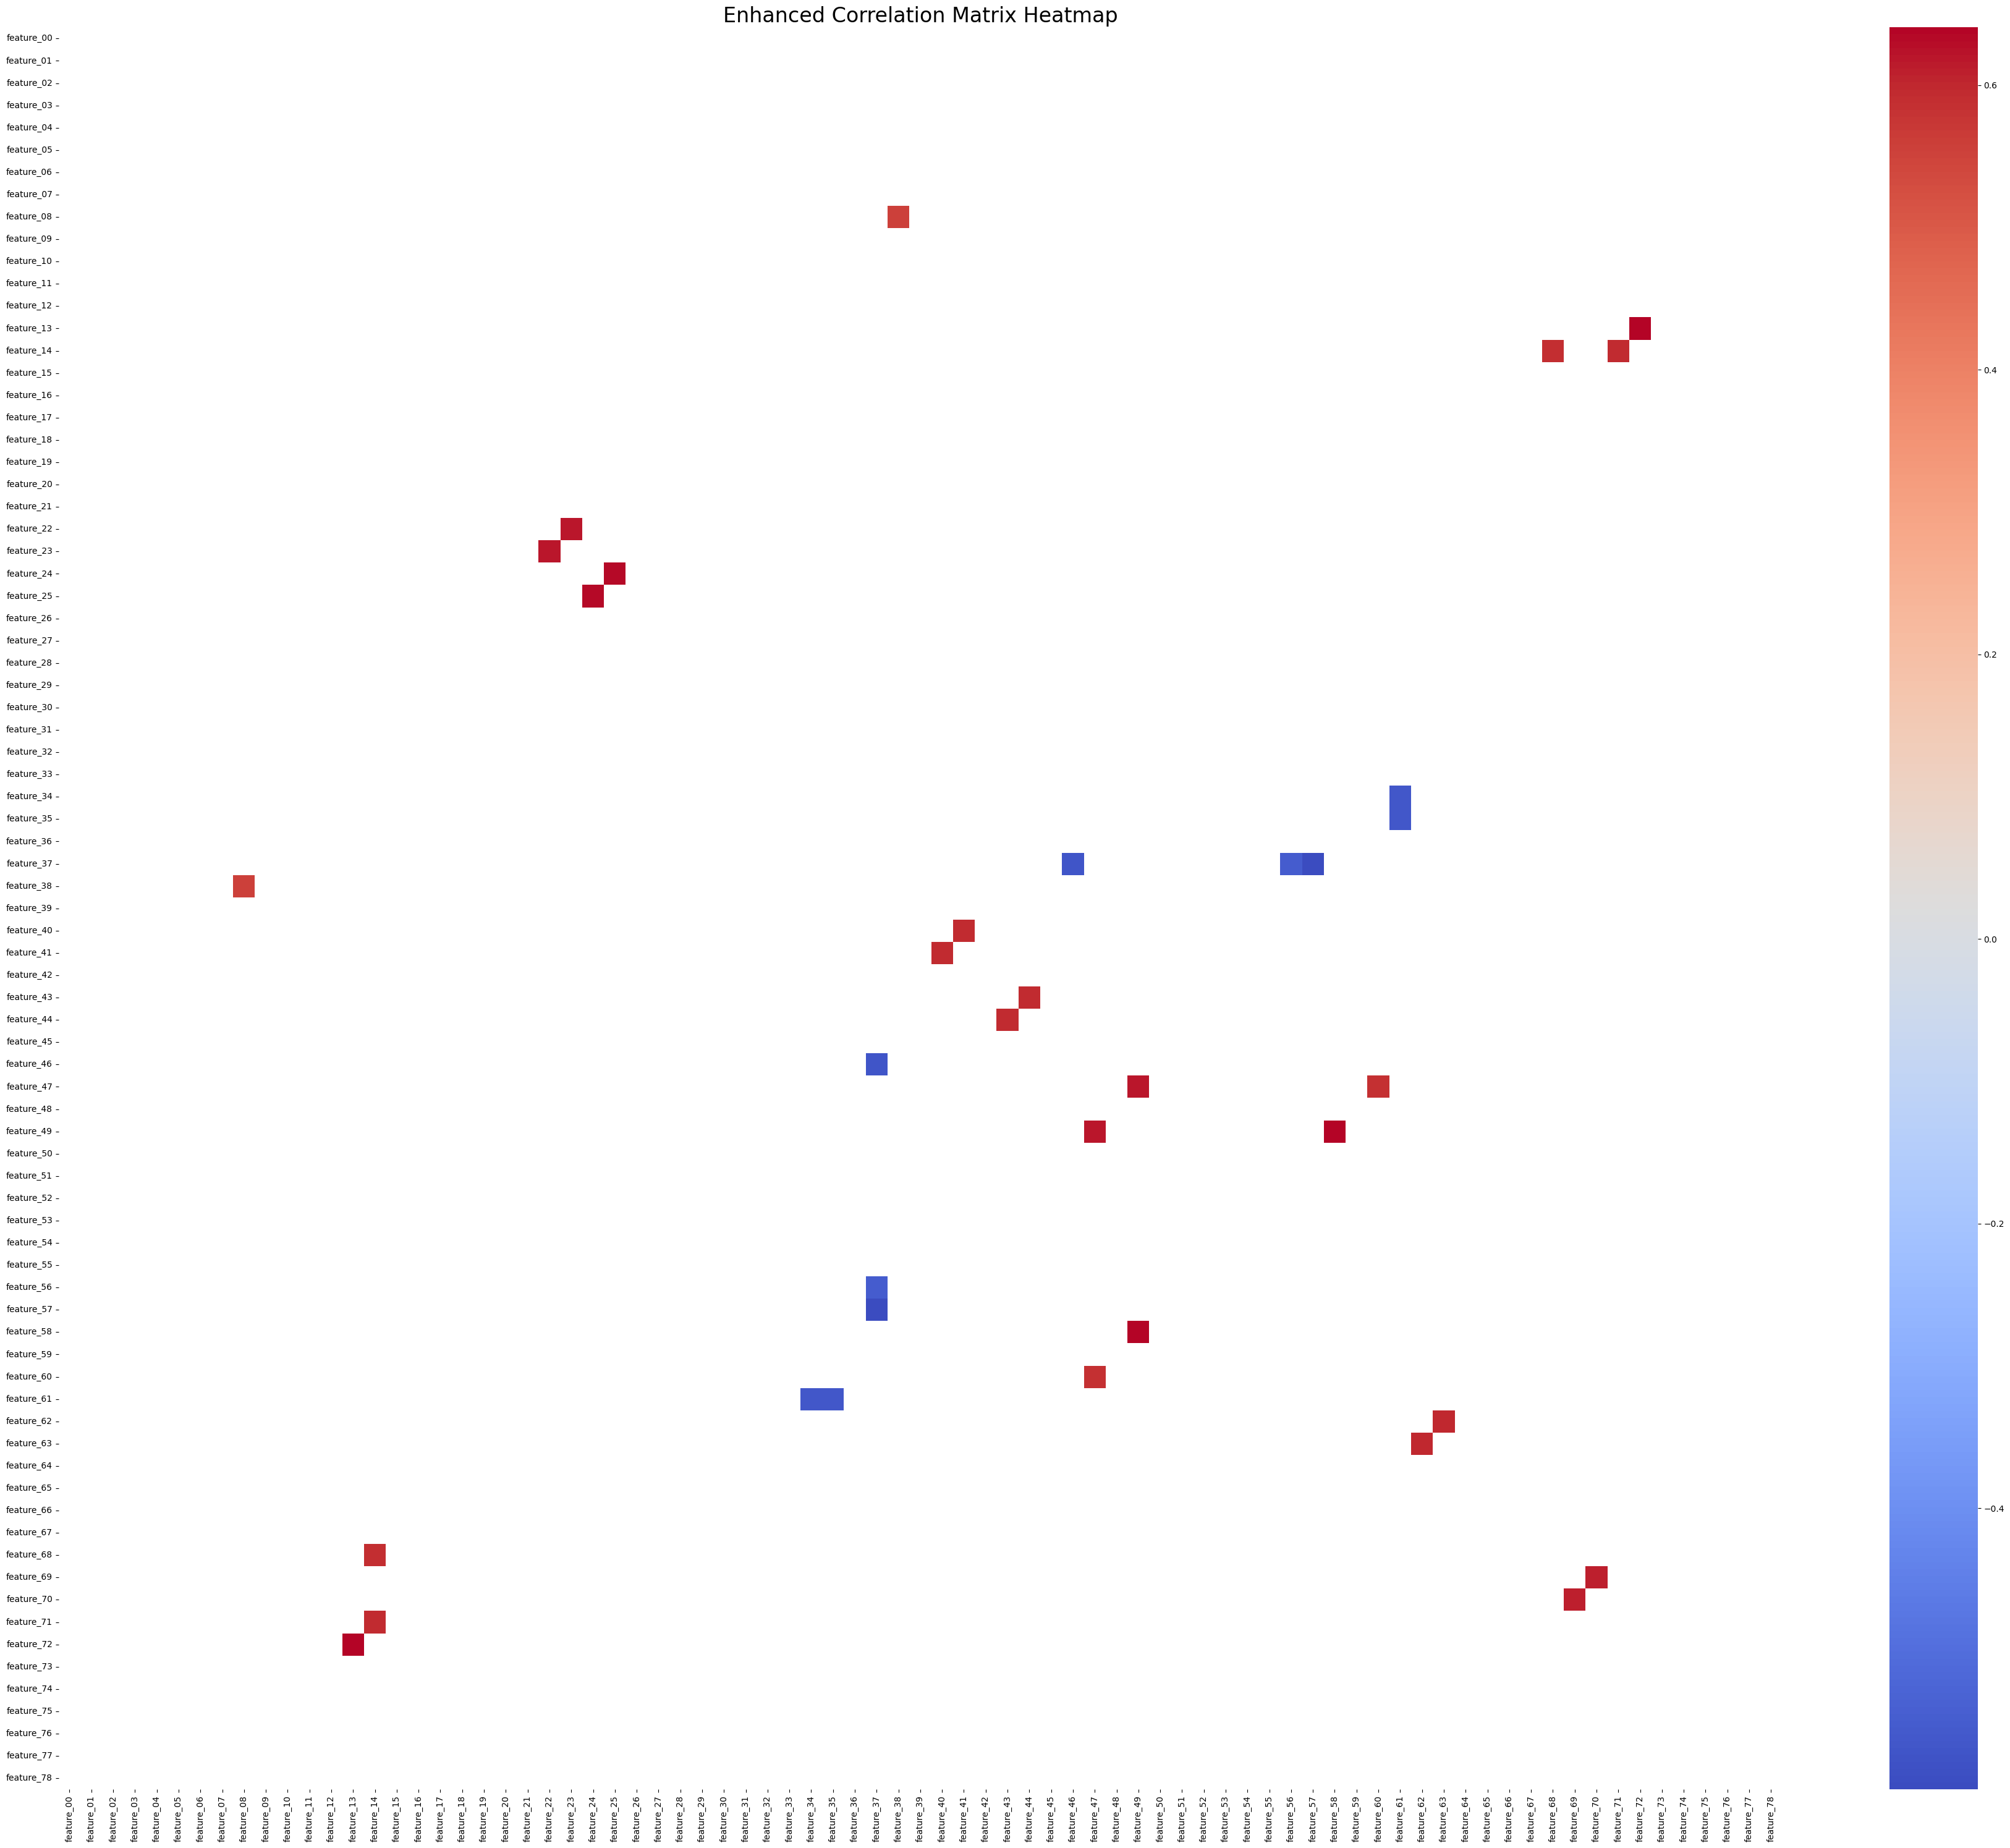

In [26]:
plt.figure(figsize=(36, 30))
mask = (corrMatrix.abs() < 0.55) | (corrMatrix.abs() > 0.65)
sns.heatmap(
    corrMatrix, 
    annot=False, 
    cmap='coolwarm', 
    cbar=True, 
    mask=mask
)
plt.xticks(fontsize=10)  
plt.yticks(fontsize=10)  
plt.title('Enhanced Correlation Matrix Heatmap', fontsize=24)
plt.tight_layout()
plt.savefig("./Plots/Correlation Matrix/55-65.png")
plt.show()
plt.close()

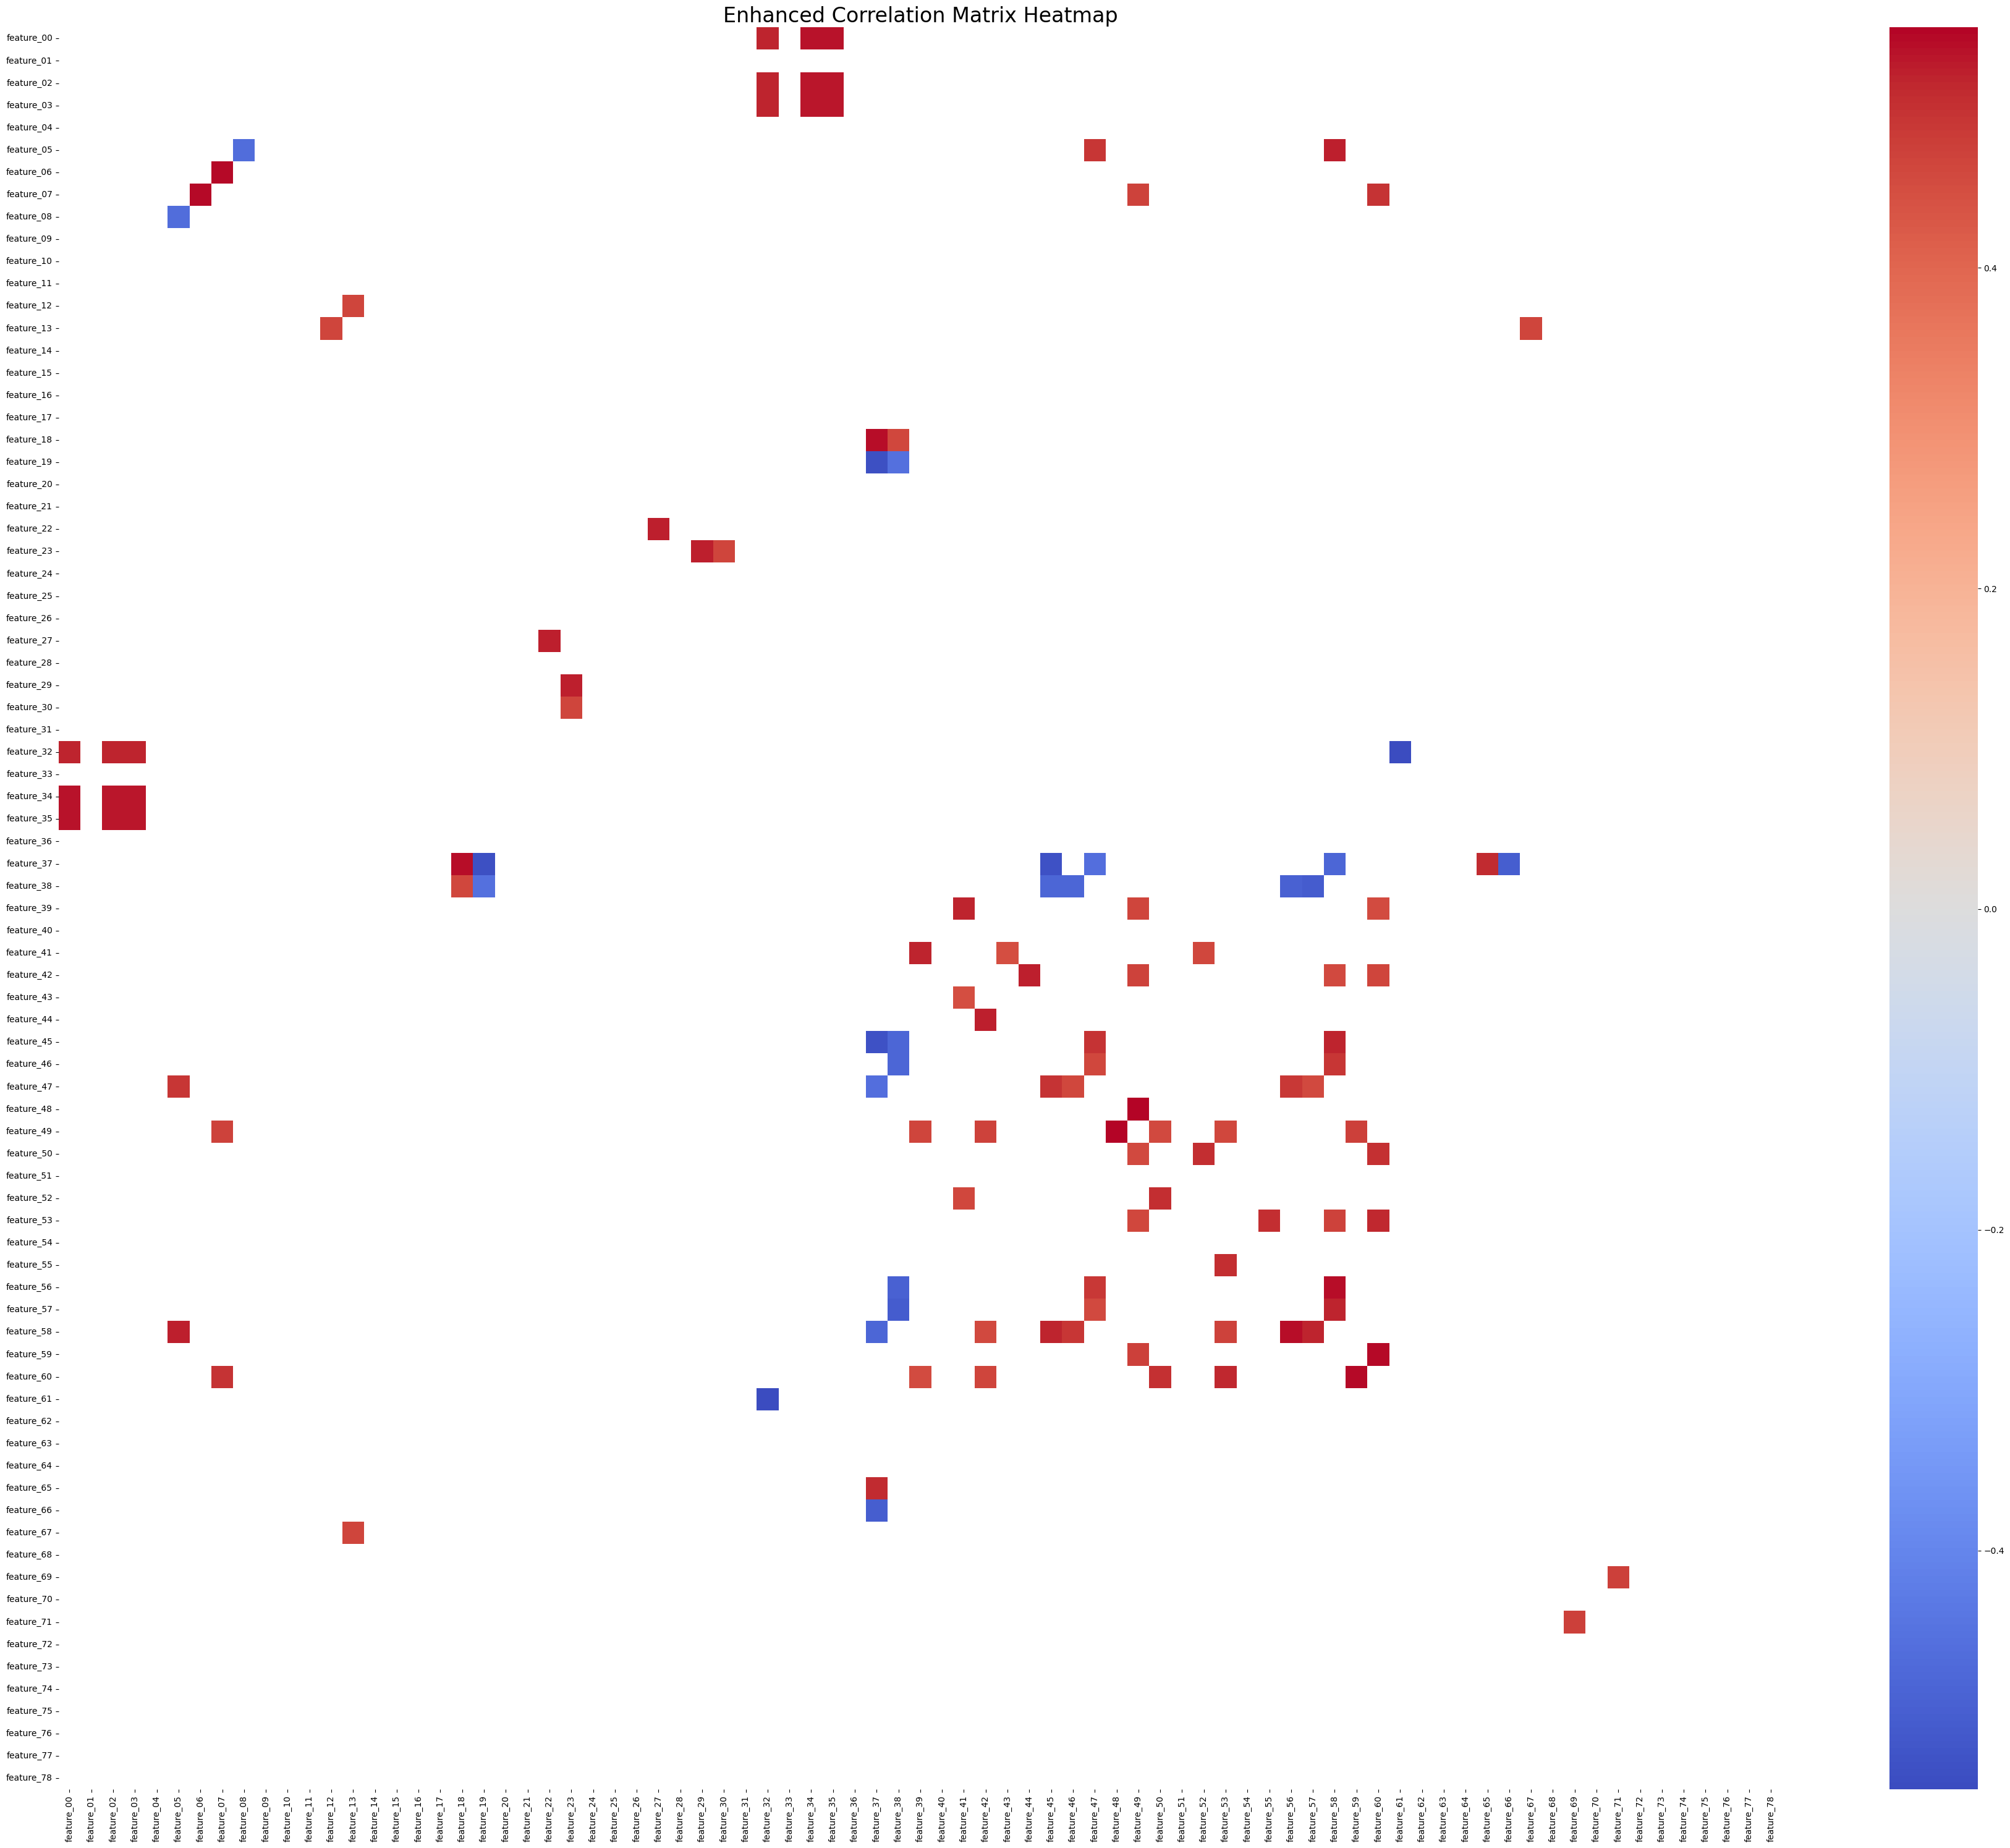

In [27]:
plt.figure(figsize=(36, 30))
mask = (corrMatrix.abs() < 0.45) | (corrMatrix.abs() > 0.55)
sns.heatmap(
    corrMatrix, 
    annot=False, 
    cmap='coolwarm', 
    cbar=True, 
    mask=mask
)
plt.xticks(fontsize=10)  
plt.yticks(fontsize=10)  
plt.title('Enhanced Correlation Matrix Heatmap', fontsize=24)
plt.tight_layout()
plt.savefig("./Plots/Correlation Matrix/45-55.png")
plt.show()
plt.close()

In [28]:
sampleStandardFeatures = sampleStandardFeatures.dropna()

In [29]:
pca = PCA(n_components=0.99)
dfPCA = pca.fit_transform(sampleStandardFeatures)

print("Explained Variance Ratio:", pca.explained_variance_ratio_)
print("Number of components:", pca.n_components_)

Explained Variance Ratio: [0.11689885 0.09250534 0.08493374 0.06867906 0.06128777 0.0546203
 0.04278425 0.03447185 0.02810785 0.02572063 0.02513617 0.02154637
 0.02070448 0.01902353 0.01711315 0.01586271 0.01456282 0.01390691
 0.01324783 0.01301515 0.01184701 0.01113896 0.01055078 0.01009009
 0.00997919 0.00924152 0.00859749 0.00836169 0.00777391 0.00730827
 0.00722647 0.00696216 0.00658295 0.0060389  0.0057269  0.00512182
 0.00479795 0.0046533  0.00458467 0.00434551 0.00421288 0.00371644
 0.00357833 0.00351511 0.0032809  0.00319656 0.00309098 0.00287829
 0.00277811 0.00251316 0.00250516 0.00241514 0.00202608 0.00193424
 0.00182219 0.00174434 0.00170991 0.00168214 0.00165402 0.00163637
 0.00116509 0.0009986  0.00093413]
Number of components: 63


In [32]:
component_weights = pd.DataFrame(pca.components_, columns=sampleStandardFeatures.columns)
print(component_weights.to_string())
component_weights.to_csv("./Info/ComponentWeight.csv", index=False)

    feature_00  feature_01  feature_02  feature_03  feature_04  feature_05  feature_06  feature_07  feature_08  feature_09  feature_10  feature_11  feature_12  feature_13  feature_14  feature_15  feature_16  feature_17  feature_18  feature_19  feature_20  feature_21  feature_22  feature_23  feature_24  feature_25  feature_26  feature_27  feature_28  feature_29  feature_30  feature_31  feature_32  feature_33  feature_34  feature_35  feature_36  feature_37  feature_38  feature_39  feature_40  feature_41  feature_42  feature_43  feature_44  feature_45  feature_46  feature_47  feature_48  feature_49  feature_50  feature_51  feature_52  feature_53  feature_54  feature_55  feature_56  feature_57  feature_58  feature_59  feature_60  feature_61  feature_62  feature_63  feature_64  feature_65  feature_66  feature_67  feature_68  feature_69  feature_70  feature_71  feature_72  feature_73  feature_74  feature_75  feature_76  feature_77  feature_78
0    -0.006414    0.012003   -0.007779   -0.00680